# Task 3 — CycleGAN Monet ↔ photo (Chaitanya)

This notebook loads the artifacts produced by the scripts in this folder and shows them with outputs, plus live
checks with the submitted generators. Training runs for many hours per run and is done with `src/train.py`, not
inside the notebook. Every model change after run 4, with its reason and result, is in `DESIGN_LOG.md`.

| Step | Command |
|---|---|
| Train / resume a run | `python task3_gan/member_chaitanya/src/train.py --config task3_gan/member_chaitanya/configs/<run>.yaml [--resume]` |
| Local metrics (FID, KID, PRDC, cycle L1, LPIPS, cosine) | `python task3_gan/member_chaitanya/evaluate_local.py --config ... --snapshot <epoch_dir>` |
| Official score (instructor's script, ported) | `src/official_eval.py`, `src/make_submission.py`, `src/score_snapshots.py` |
| Failure candidates | `src/failure_cases.py` |
| Human audit | `src/human_audit.py build` / `score` |

Naming follows Kaggle: **A = Monet, B = photo**. The submitted model is `checkpoints/full_run18/epoch_123_ema/`.

In [1]:
import json, sys, warnings
from pathlib import Path
warnings.filterwarnings("ignore")  # library warnings would print local install paths

SRC = Path.cwd() if (Path.cwd() / 'models.py').exists() else Path('task3_gan/member_chaitanya/src').resolve()
sys.path.insert(0, str(SRC))
import numpy as np, pandas as pd, torch
from PIL import Image as PILImage
from IPython.display import Image, display
from common import MEMBER_DIR, load_config, repo_path, run_paths
from data import eval_transform, list_images, load_rgb
from models import make_generator, make_discriminator, count_params
pd.set_option('display.max_columns', None); pd.set_option('display.width', 200); pd.set_option('display.max_colwidth', 100)
cfg = load_config('task3_gan/member_chaitanya/configs/full_run18.yaml')
OUT = MEMBER_DIR / 'outputs'
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device, torch.cuda.get_device_name(0) if device == 'cuda' else '')

cuda NVIDIA GeForce RTX 4090


## 3.1 Data: two unpaired domains

Monet paintings (A): 300 | photos (B): 7038


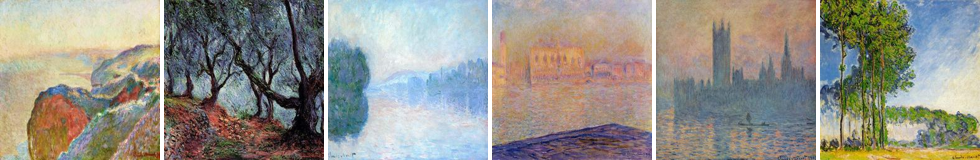

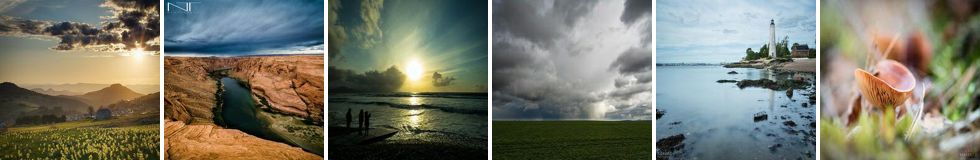

In [2]:
monet = list_images(repo_path(cfg['data']['monet_dir'])); photo = list_images(repo_path(cfg['data']['photo_dir']))
print('Monet paintings (A):', len(monet), '| photos (B):', len(photo))
def row(paths, size=160):
    ims = [load_rgb(p).resize((size, size)) for p in paths]
    canvas = PILImage.new('RGB', (size * len(ims) + 4 * (len(ims) - 1), size), 'white')
    for i, im in enumerate(ims): canvas.paste(im, (i * (size + 4), 0))
    return canvas
display(row(monet[:6])); display(row(photo[:6]))

## 3.1 Model: 2 generators + 2 discriminators (configuration of the final run lineage)

In [3]:
print(json.dumps(cfg['model'], indent=1))
G = make_generator(cfg['model']); D = make_discriminator(cfg['model'])
print(f'generator params {count_params(G):,} (x2) | discriminator params {count_params(D):,} (x2)')
print(G)

{
 "ngf": 64,
 "n_res_blocks": 9,
 "n_downsampling": 2,
 "upsampling": "nearest_conv",
 "ndf": 64,
 "d_scales": 2,
 "norm": "instance",
 "init_std": 0.02
}


generator params 11,378,179 (x2) | discriminator params 5,529,474 (x2)
ResnetGenerator(
  (net): Sequential(
    (0): ReflectionPad2d((3, 3, 3, 3))
    (1): Conv2d(3, 64, kernel_size=(7, 7), stride=(1, 1))
    (2): InstanceNorm2d(64, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
    (3): ReLU(inplace=True)
    (4): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (5): InstanceNorm2d(128, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (8): InstanceNorm2d(256, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
    (9): ReLU(inplace=True)
    (10): ResidualBlock(
      (body): Sequential(
        (0): ReflectionPad2d((1, 1, 1, 1))
        (1): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1))
        (2): InstanceNorm2d(256, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
        (3): Re

## 3.1 Translation and cycle consistency (live, submitted generators)

photo -> Monet -> photo (input | translation | reconstruction)


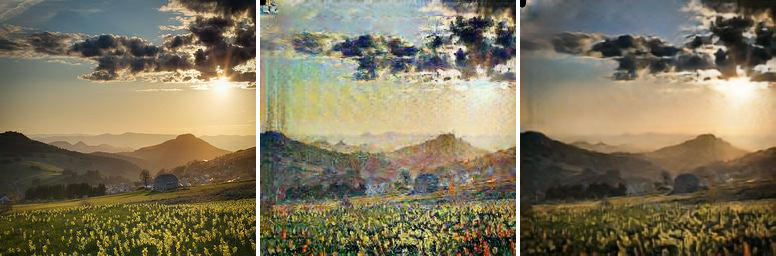

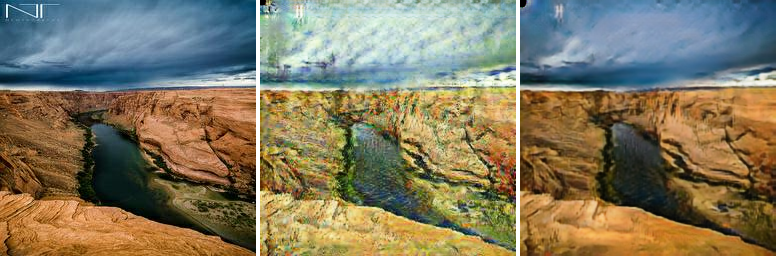

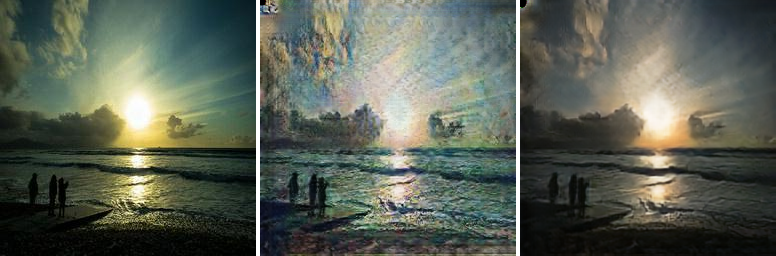

G_B2A: cycle L1 per image [0.0468 0.0545 0.0413]  vs L1 to a different image [0.195  0.218  0.2461]
Monet -> photo -> Monet


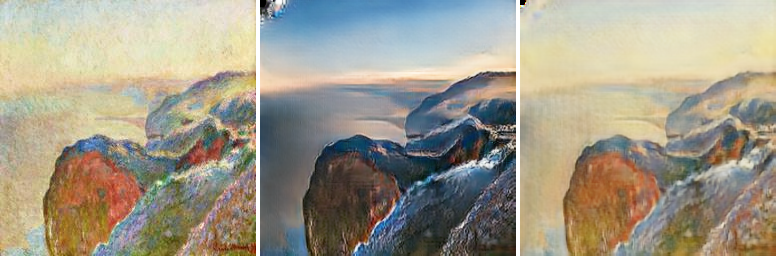

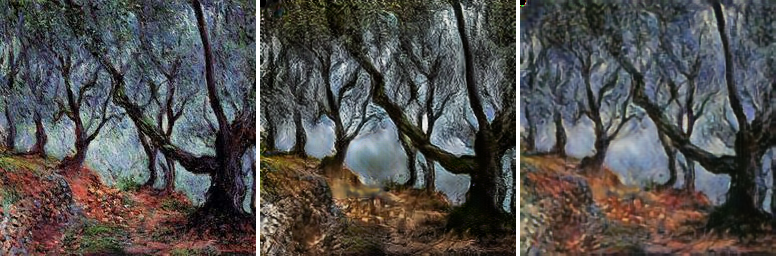

G_A2B: cycle L1 per image [0.0353 0.0653]  vs L1 to a different image [0.3559 0.3559]


In [4]:
ckpt = run_paths(cfg['run_id'])['checkpoints'] / 'epoch_123_ema'
gens = {}
for k in ('G_A2B', 'G_B2A'):
    g = make_generator(cfg['model']).to(device).eval(); g.load_state_dict(torch.load(ckpt / f'{k}.pt', map_location=device)); gens[k] = g
tf = eval_transform(cfg['data']['crop_size'])
to_pil = lambda t: PILImage.fromarray(((t.clamp(-1, 1) + 1) * 127.5).round().byte().permute(1, 2, 0).cpu().numpy())
def show(paths, fwd, back):
    x = torch.stack([tf(load_rgb(p)) for p in paths]).to(device)
    with torch.no_grad():
        y = gens[fwd](x); r = gens[back](y)
    for i in range(len(paths)):
        canvas = PILImage.new('RGB', (3 * 256 + 8, 256), 'white')
        for j, t in enumerate((x[i], y[i], r[i])): canvas.paste(to_pil(t), (j * 260, 0))
        display(canvas)
    cyc = (r - x).abs().mean(dim=(1, 2, 3)) / 2
    other = (x.roll(1, 0) - x).abs().mean(dim=(1, 2, 3)) / 2
    print(f'{fwd}: cycle L1 per image {cyc.cpu().numpy().round(4)}  vs L1 to a different image {other.cpu().numpy().round(4)}')
print('photo -> Monet -> photo (input | translation | reconstruction)'); show(photo[:3], 'G_B2A', 'G_A2B')
print('Monet -> photo -> Monet'); show(monet[:2], 'G_A2B', 'G_B2A')

## 3.1 Training behaviour: stability across runs (losses, gradient norms, NaNs)

,run_id,final_epoch,param_count_total,train_time_s,train_images_per_sec,peak_memory_mb,max_grad_norm_G,max_grad_norm_D,nan_count
0,full_run01,"{'epoch': 40, 'iters': 7038, 'epoch_time_s': 661.4247580999509, 'iters_per_s': 10.64066609816328...",28285832,26494.395393,21.251287,19153.687500,1561.698486,482.868744,0
1,full_run02,"{'epoch': 40, 'iters': 7038, 'epoch_time_s': 714.7946409999859, 'iters_per_s': 9.846184619059196...",28285832,28101.570792,20.035891,19153.687988,1627.257935,381.466034,0
2,full_run02b,"{'epoch': 80, 'iters': 7038, 'epoch_time_s': 740.9899148000404, 'iters_per_s': 9.498104980145698...",28285832,58038.926029,19.402151,19485.713379,1824.526733,381.466034,0
3,full_run06,"{'epoch': 90, 'iters': 7038, 'epoch_time_s': 1413.389281899901, 'iters_per_s': 4.979519860614341...",28285832,72436.610792,17.488946,19577.524902,1824.526733,381.466034,0
4,full_run09,"{'epoch': 98, 'iters': 7038, 'epoch_time_s': 1361.10346699995, 'iters_per_s': 5.17080454986473, ...",28285832,83771.950949,16.466705,19577.524902,1824.526733,381.466034,0
5,full_run10,"{'epoch': 104, 'iters': 7038, 'epoch_time_s': 1506.178143300116, 'iters_per_s': 4.67275403730090...",33815306,93442.969405,15.666283,19599.612793,1824.526733,381.466034,0
6,full_run11,"{'epoch': 40, 'iters': 7038, 'epoch_time_s': 797.6647594000679, 'iters_per_s': 8.823255530673507...",33815306,42867.390992,13.134459,19265.087402,636.094055,130.007217,0
7,full_run12,"{'epoch': 112, 'iters': 7038, 'epoch_time_s': 1115.3448530999012, 'iters_per_s': 6.3101559848858...",33815306,102656.932237,15.357092,18881.876465,1824.526733,381.466034,0
8,full_run14,"{'epoch': 48, 'iters': 7038, 'epoch_time_s': 882.6563808000647, 'iters_per_s': 7.973657873090498...",33815306,49975.321897,13.519633,19662.406738,636.094055,130.910873,0
9,full_run15,"{'epoch': 96, 'iters': 7038, 'epoch_time_s': 743.3648066001479, 'iters_per_s': 9.467760563200438...",28285832,77115.345802,17.523049,19577.524902,1824.526733,381.466034,0


full_run01


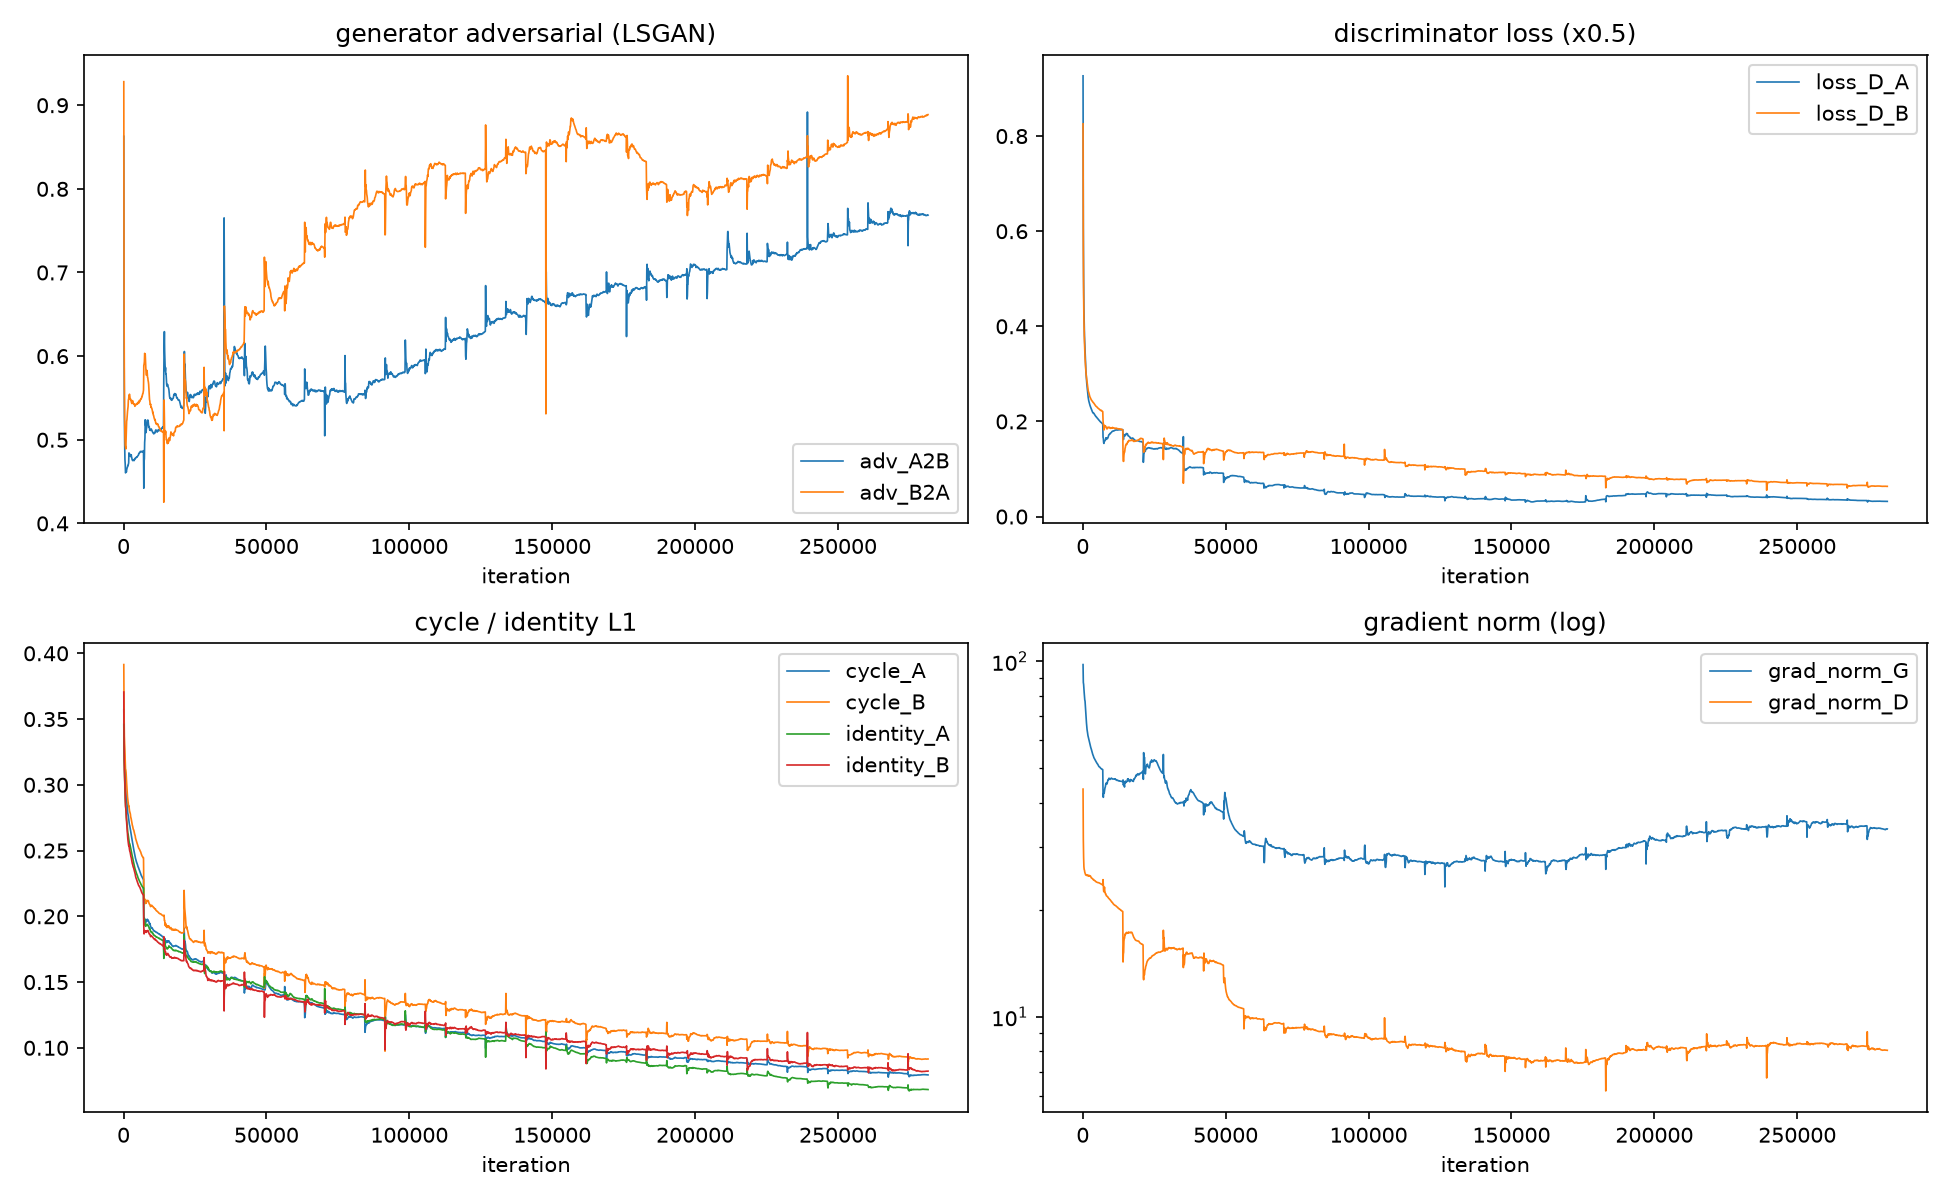

full_run07


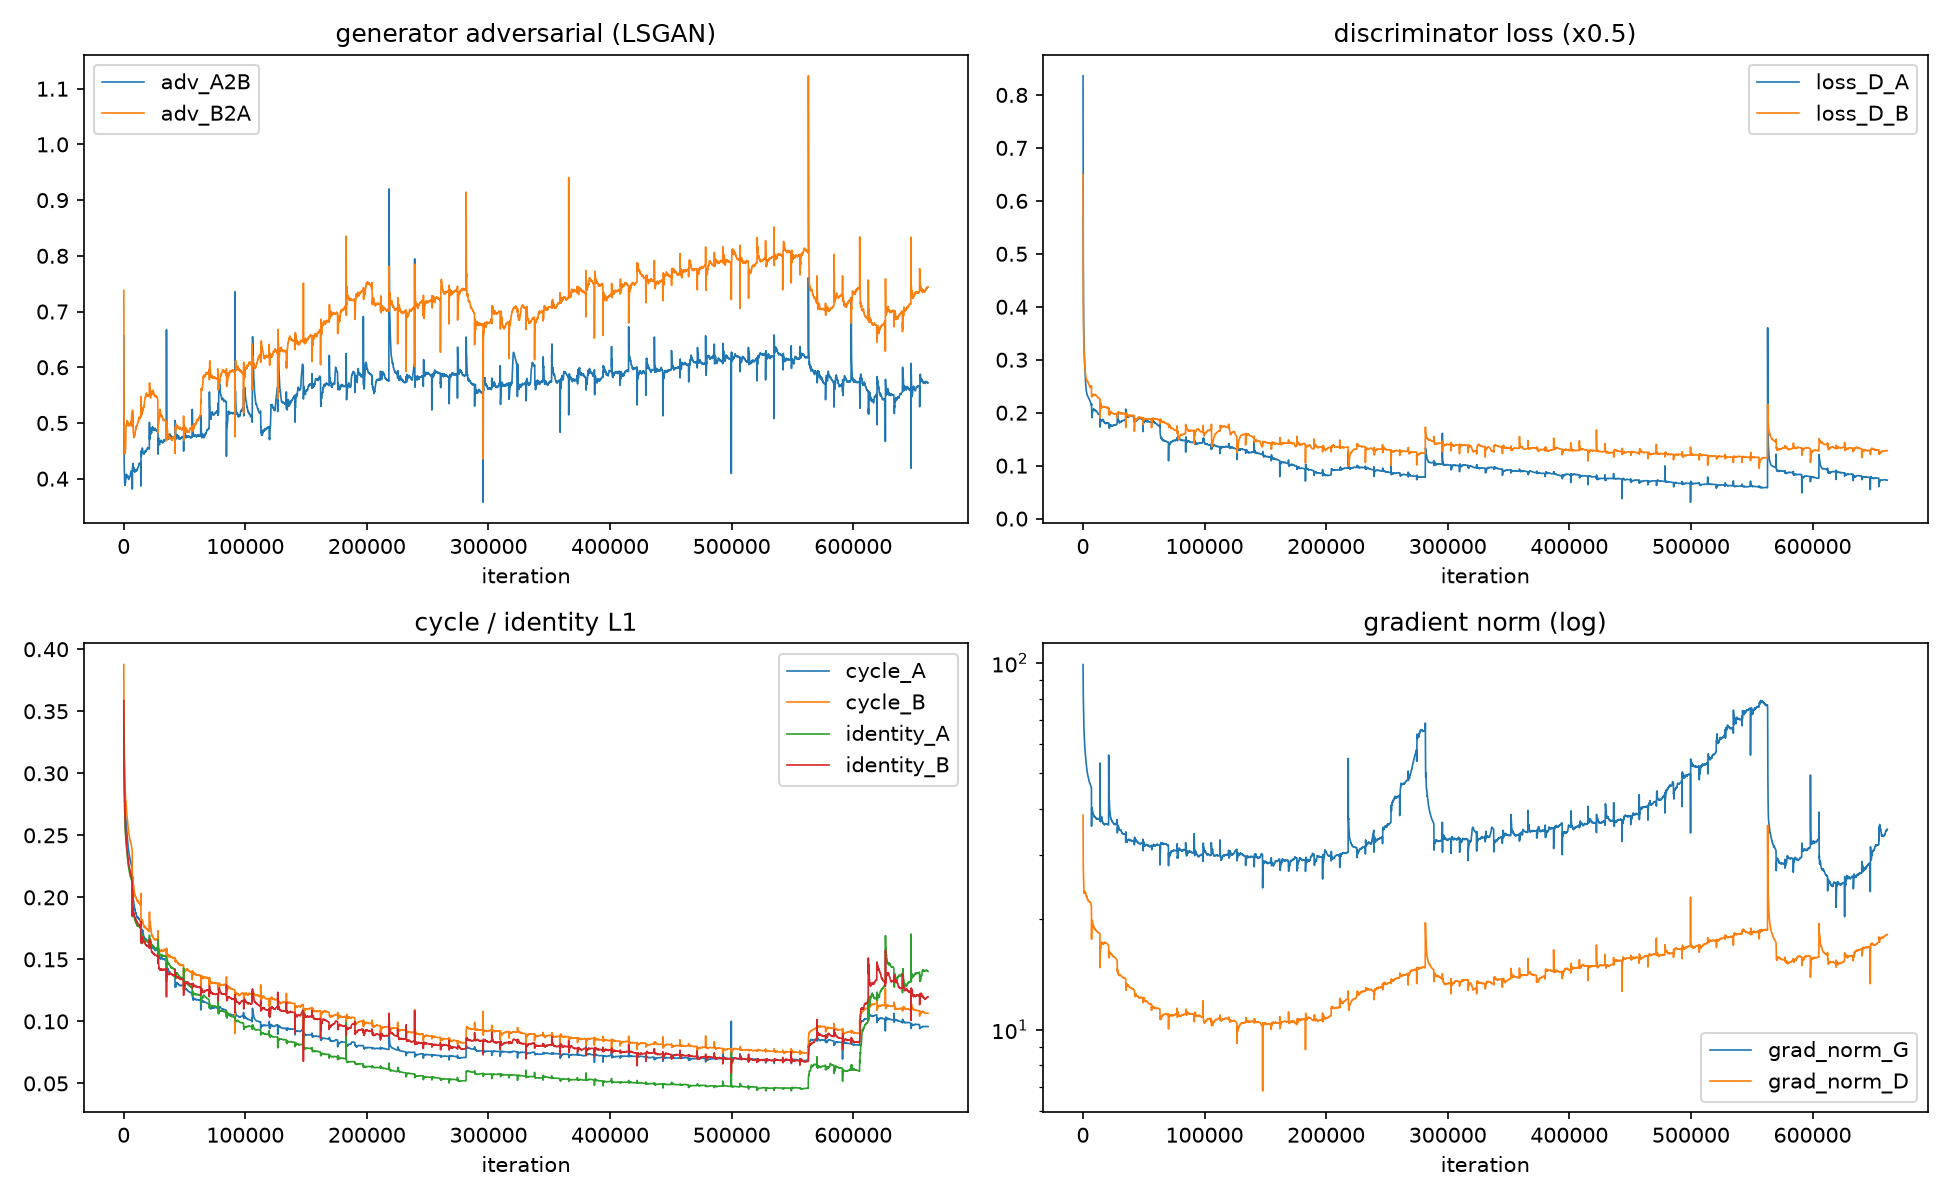

full_run18


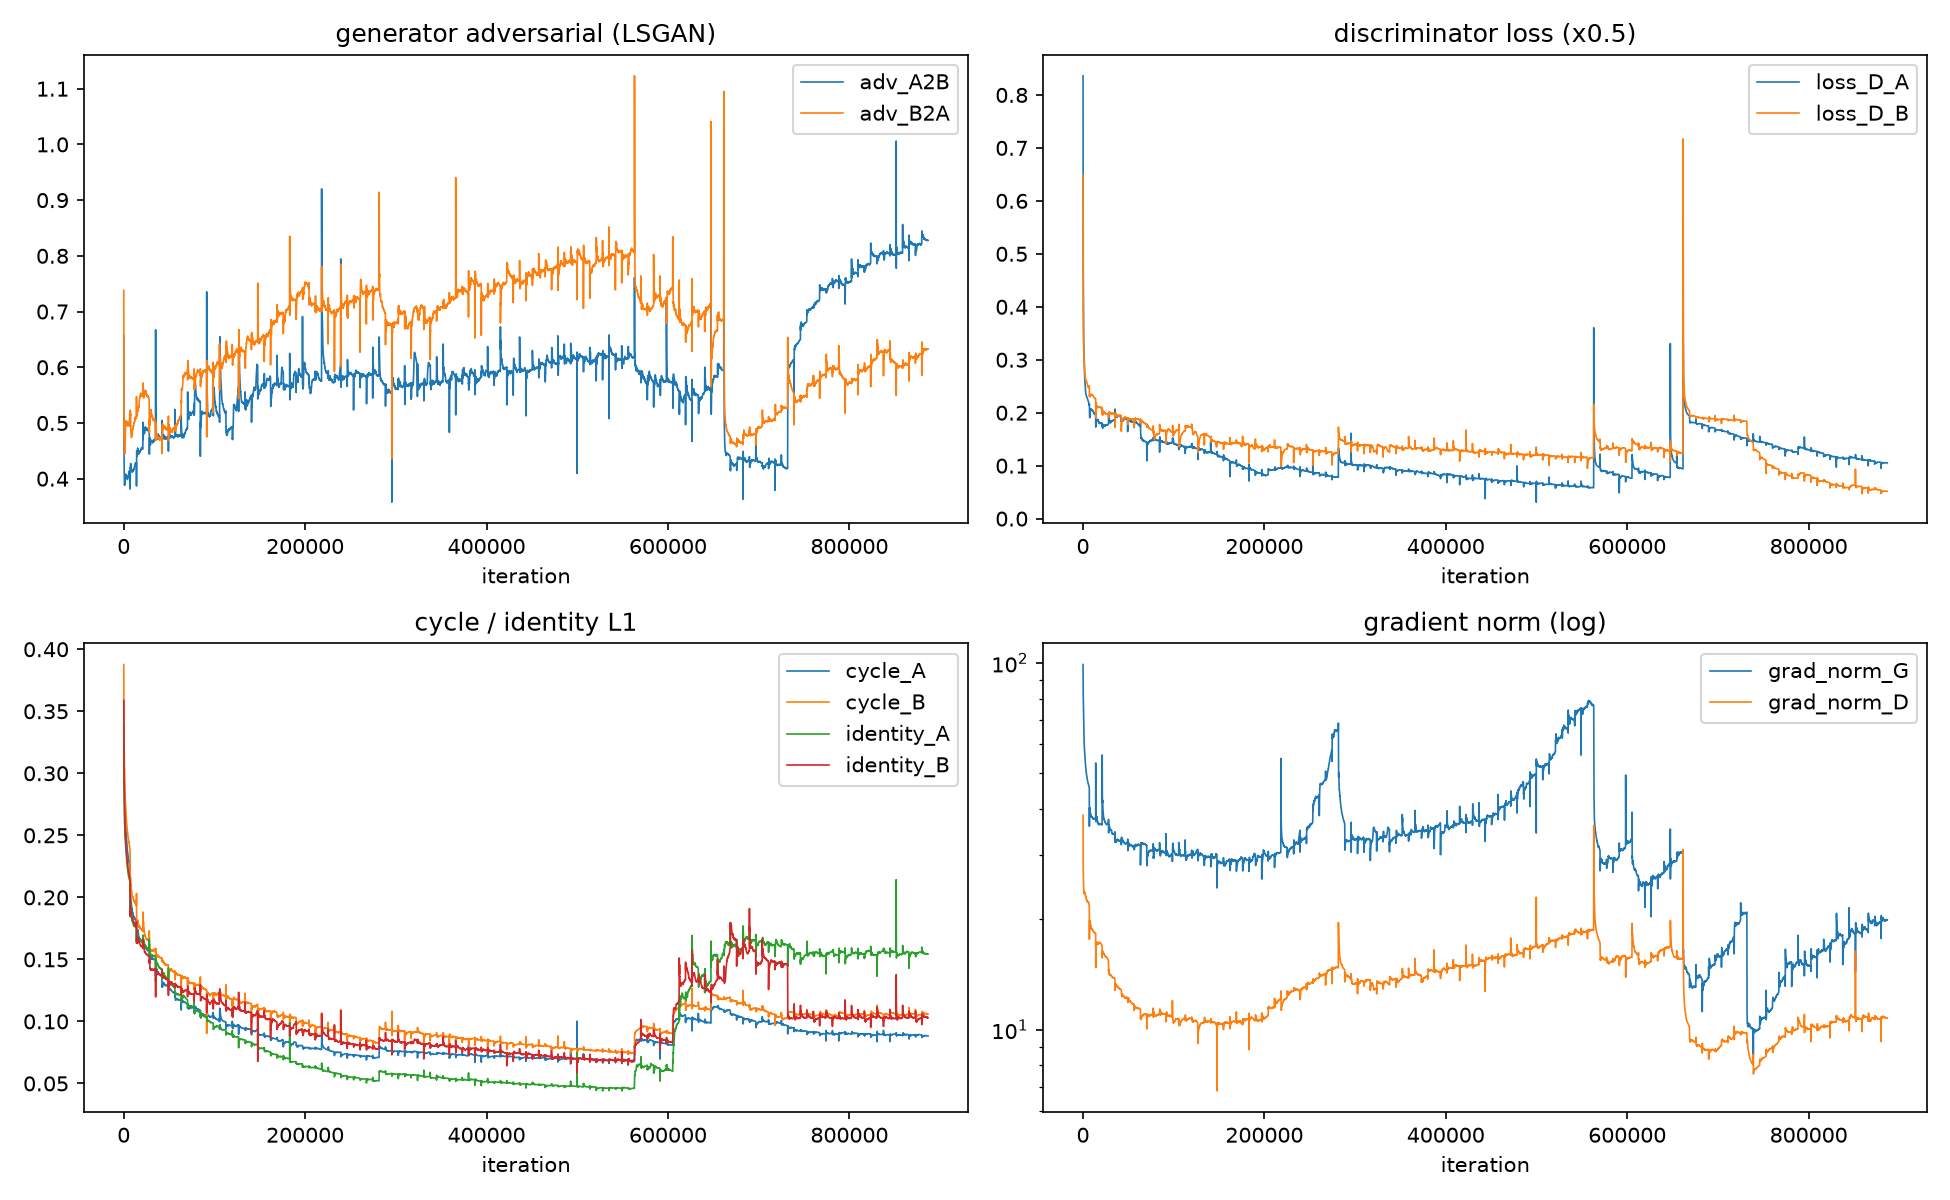

In [5]:
rows = []
for d in sorted(OUT.glob('full_run*')):
    f = d / 'train_summary.json'
    if f.exists():
        s = json.loads(f.read_text())
        rows.append({k: s.get(k) for k in ('run_id', 'final_epoch', 'param_count_total', 'train_time_s', 'train_images_per_sec',
                                           'peak_memory_mb', 'max_grad_norm_G', 'max_grad_norm_D', 'nan_count')})
display(pd.DataFrame(rows))
for r in ('full_run01', 'full_run07', 'full_run18'):
    print(r); display(Image(str(OUT / r / 'loss_curves.png')))

## 3.2 Official score progression (instructor's script: first 300 images per folder, both directions)

In [6]:
rows = []
for d in sorted(OUT.glob('full_run*')):
    f = d / 'snapshot_scores.csv'
    if f.exists():
        s = pd.read_csv(f); b = s.loc[s.score.idxmax()]
        rows.append({'run': d.name, 'snapshots': len(s), 'best_snapshot': b.snapshot, 'FID_A2B': b.FID_A2B, 'FID_B2A': b.FID_B2A,
                     'MiFID': b.MiFID, 'score': b.score})
display(pd.DataFrame(rows).round(4))
print('submitted:', (OUT / 'pred_source.txt').read_text().strip())
print(json.dumps(json.loads((OUT / 'official_eval.json').read_text()), indent=1)[:1200])
print((MEMBER_DIR / 'submission.csv').read_text())

,run,snapshots,best_snapshot,FID_A2B,FID_B2A,MiFID,score
0,full_run02,9,epoch_035,105.6460,99.4154,0.4082,-51.4695
1,full_run02b,13,epoch_avg055-080,99.8089,98.3054,0.4042,-49.7307
2,full_run03,4,epoch_010,167.4383,164.8475,0.4229,-83.2829
3,full_run04,2,epoch_010,127.4144,119.0448,0.4144,-61.8220
4,full_run05,2,epoch_085_ema,99.6001,100.4382,0.4045,-50.2118
5,full_run06,17,epoch_soupB,98.5581,98.6018,0.4039,-49.4919
6,full_run07,8,epoch_088_ema,98.1213,96.7799,0.4019,-48.9262
7,full_run08,4,epoch_090_ema,99.3936,96.1690,0.4022,-49.0918
8,full_run09,7,epoch_096_ema,101.6546,96.1636,0.3979,-49.6535
9,full_run10,13,epoch_096_ema,99.5928,96.1929,0.4012,-49.1470


submitted: checkpoints/full_run18/epoch_123_ema (G_A2B = frozen copy of full_blends/epoch_b1_r7ema88-90, G_B2A = run-18 EMA 123); written by the run-18 orchestrator's evaluate_local --snapshot epoch_123_ema on 2026-10-04, submitted as Kaggle -48.2029
{
 "FID_B2A": 94.20604278878164,
 "MiFID_B2A": 0.39280104637145996,
 "FID_A2B": 97.8062318179777,
 "MiFID_A2B": 0.4067187011241913,
 "FID": 96.00613730337967,
 "MiFID": 0.3997598737478256,
 "counts": {
  "real_monet": 300,
  "real_photo": 300,
  "a2b": 300,
  "b2a": 300
 },
 "pred_a2b": "task3_gan/member_chaitanya/outputs/pred_A2B",
 "pred_b2a": "task3_gan/member_chaitanya/outputs/pred_B2A"
}
ID,FID,MiFID
1,96.00613730337967,0.3997598737478256



## 3.2 Full metrics (both directions)

In [7]:
display(pd.read_csv(MEMBER_DIR / 'full_metrics_report.csv').set_index(['run_id', 'direction']).T)

run_id                                                                                        full_run01                                                                                             \
direction                                                                             A2B (Monet->photo)                                                                         B2A (photo->Monet)   
checkpoint                                                               checkpoints/full_run01/G_A2B.pt                                                            checkpoints/full_run01/G_B2A.pt   
fid                                                                                            87.486794                                                                                  91.458031   
kid_mean                                                                                        0.024389                                                                                     0.0193   
kid_std                                                                                         0.002581                                                                                   0.002956   
gen_precision                                                                                   0.683333                                                                                   0.406667   
gen_recall                                                                                          0.43                                                                                       0.73   
density                                                                                         0.725333                                                                                   0.263333   
coverage                                                                                            0.76                                                                                   0.586667   
cycle_l1                                                                                         0.04578                                                                                   0.050016   
lpips                                                                                           0.359806                                                                                   0.417425   
content_cosine_sim                                                                              0.782075                                                                                   0.740466   
final_g_loss                                                                                    4.119121                                                                                   4.119121   
final_d_loss                                                                                    0.063499                                                                                   0.031898   
cycle_loss                                                                                      0.079385                                                                                   0.091525   
identity_loss                                                                                    0.08231                                                                                   0.068249   
max_grad_norm                                                                      G=1561.698; D=482.869                                                                      G=1561.698; D=482.869   
nan_count                                                                                              0                                                                                          0   
human_style                                                                                          NaN                                                                                        NaN   
human_content       

## 3.2 Failure candidates (per-image scores of the submitted model; labels in `failure_analysis.md`)

B2A 7038 images


,count,mean,std,min,25%,50%,75%,max
cycle_l1,7038.0,0.0523,0.0154,0.0113,0.0416,0.0501,0.0603,0.1926
lpips_change,7038.0,0.4412,0.1003,0.1989,0.3691,0.4293,0.5014,0.8763
lpips_rec,7038.0,0.2984,0.0882,0.1052,0.2385,0.2818,0.3381,0.9968
content_cos,7038.0,0.7209,0.0856,0.3565,0.6657,0.7291,0.7844,0.9446


A2B 300 images


,count,mean,std,min,25%,50%,75%,max
cycle_l1,300.0,0.0445,0.0109,0.0210,0.0368,0.0432,0.0506,0.0859
lpips_change,300.0,0.4114,0.0955,0.1897,0.3461,0.4013,0.4709,0.7580
lpips_rec,300.0,0.3435,0.0935,0.1523,0.2820,0.3294,0.3910,0.7768
content_cos,300.0,0.7390,0.0690,0.5304,0.6926,0.7441,0.7866,0.9247


B2A_high_cycle_error/1_d0a1eed9dd.png


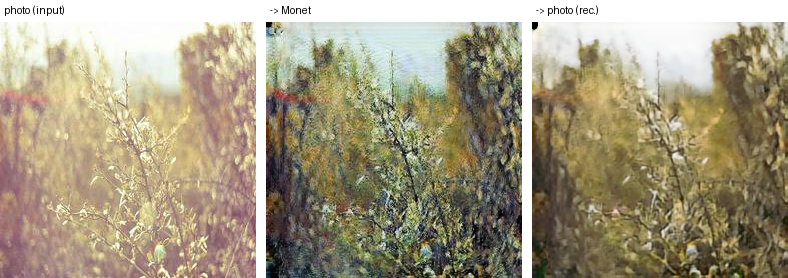

B2A_low_content/1_3a7a0992dd.png


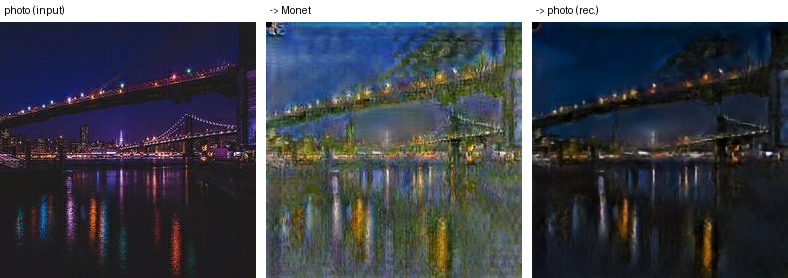

A2B_high_cycle_error/1_4f7e01f097.png


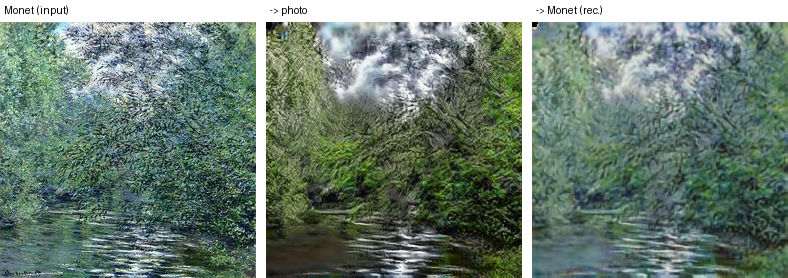

In [8]:
for tag in ('B2A', 'A2B'):
    s = pd.read_csv(OUT / 'failure_cases' / f'per_image_scores_{tag}.csv')
    print(tag, len(s), 'images'); display(s.describe().T.round(4))
for p in ('B2A_high_cycle_error/1_d0a1eed9dd.png', 'B2A_low_content/1_3a7a0992dd.png', 'A2B_high_cycle_error/1_4f7e01f097.png'):
    print(p); display(Image(str(OUT / 'failure_cases' / p)))

## 3.2 Blinded human audit (30 fixed samples, 2 raters)

In [9]:
A = OUT / 'human_audit'
res = A / 'audit_results.json'
if res.exists():
    print(json.dumps(json.loads(res.read_text()), indent=1))
else:
    print('Pending: the two raters fill in rater_1.csv / rater_2.csv from sheet.html, then run `human_audit.py score`.')
    print('fixed inputs:', (A / 'inputs.txt').read_text().count(chr(10)), '| items on the sheet:', len(pd.read_csv(A / 'rater_template.csv')))

Pending: the two raters fill in rater_1.csv / rater_2.csv from sheet.html, then run `human_audit.py score`.
fixed inputs: 30 | items on the sheet: 30
